In [79]:
!python -V

Python 3.11.11


In [80]:
import pandas as pd

In [81]:
import pickle

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

In [83]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import root_mean_squared_error

In [84]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    if 'lpep_pickup_datetime' in df.columns:
        pickup, dropoff = 'lpep_pickup_datetime', 'lpep_dropoff_datetime'
    else:
        pickup, dropoff = 'tpep_pickup_datetime', 'tpep_dropoff_datetime'

    df[pickup] = pd.to_datetime(df[pickup])
    df[dropoff] = pd.to_datetime(df[dropoff])
    df['duration'] = (df[dropoff] - df[pickup]).dt.total_seconds() / 60
    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [85]:
# df_train = read_dataframe('./data/green_tripdata_2021-01.parquet')
# df_val = read_dataframe('./data/green_tripdata_2021-02.parquet')
df_train = read_dataframe('./data/yellow_tripdata_2021-01.parquet')
df_val = read_dataframe('./data/yellow_tripdata_2021-02.parquet')

In [86]:
len(df_train), len(df_val), (df_train.tpep_dropoff_datetime - df_train.tpep_pickup_datetime).std()

(1343254, 1340859, Timedelta('0 days 00:08:51.916158'))

In [87]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [88]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [89]:
# show the first five rows (:5) of the training matrix using the corresponding column names of the Vector
df_peek = pd.DataFrame(X_train[:5].toarray(), columns=dv.get_feature_names_out())
# select the columns with elements that aren't zero in at least one of the five rows
df_peek.loc[:, (df_peek != 0).any(axis=0)]


,PU_DO=132_165,PU_DO=138_132,PU_DO=142_43,PU_DO=224_68,PU_DO=68_33,trip_distance
0,0.0,0.0,1.0,0.0,0.0,2.10
1,1.0,0.0,0.0,0.0,0.0,14.70
2,0.0,1.0,0.0,0.0,0.0,10.60
3,0.0,0.0,0.0,0.0,1.0,4.94
4,0.0,0.0,0.0,1.0,0.0,1.60


In [90]:
import numpy as np

def fix_sparse(X):
    X = X.tocsr()
    X.indices = X.indices.astype(np.int32)
    X.indptr = X.indptr.astype(np.int32)
    return X

X_train = fix_sparse(X_train)
X_val = fix_sparse(X_val)

In [91]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [92]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

4.992296237937105

/var/folders/v1/q75wk2jj55s9f_54lch6rdy80000gn/T/ipykernel_56770/1672306066.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/var/folders/v1/q75wk2jj55s9f_54lch6rdy80000gn/T/ipykernel_56770/1672306066.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, lab

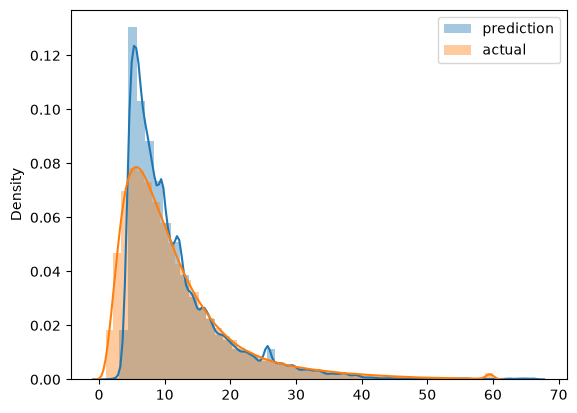

In [93]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend()

In [94]:
df_train.shape, df_val.shape

((1343254, 21), (1340859, 21))

In [95]:
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)